# Plotting of Pre-Computed PDFs for Waste Thermophysical and Compositional Properties

This notebook visualizes previously generated probability density functions (PDFs) for waste material properties derived from hierarchical stochastic aggregation.

The PDFs are read from CSV files and correspond to:

- **Thermophysical properties (including HHV)**  
  - Specific density
  - Thermal conductivity
  - Specific heat capacity
  - High heat value (dry-ash-free basis) 

- **Proximate Analysis (PA)**  
  - Moisture Content  
  - Volatile Matter  
  - Char  
  - Ash  

- **Elemental Analysis (EA)**  
  - Carbon
  - Hydrogen
  - Nitrogen  
  - Sulfur
  - Oxygen
  - Chlorine

## Content:

1. Functions
2. Plot helpers
3. Thermophysical properties of main groups
4. Thermophysical properties of waste samples
5. Proximate analysis of main groups
6. Proximate analysis of waste samples
7. Elemental analysis of main groups
8. Elemental analysis of waste samples

---

## Data Source

-  `PDFs_TPP_main_groups_1000k_cases`
- `PDFs_TPP_waste_samples_1000k_cases.csv`
- `PDFs_PA_main_groups_1000k_cases.csv`
- `PDFs_PA_waste_samples_1000k_cases.csv`
- `PDFs_EA_main_groupss_1000k_cases.csv`
- `PDFs_EA_waste_samples_1000k_cases.csv`
- `PDFs_EA_Cl_All_1000k_cases.csv`

---

## Data Structure

### Main Groups
- Paper
- Organic
- Plastic

### Waste Samples
- Baseline
- S1
- S2
- S3

---

## Statistical Quantities Shown in the Plots

For each PDF, the following are computed numerically: Mean, Median, Central 68% interval (q16–q84)

The 68% interval is highlighted in the plots to visualize uncertainty spread.

---

In [72]:
# --- Core numerical libraries ---
import numpy as np
import pandas as pd

# --- Matplotlib configuration ---
from matplotlib import pyplot as plt
%matplotlib inline
from matplotlib import rcParams
rcParams['mathtext.fontset'] = 'stix'
rcParams['font.family'] = 'STIXGeneral'
rcParams['font.size'] = 25

# --- Plot customization utilities ---

from matplotlib.colors import to_rgb
from matplotlib.ticker import FormatStrFormatter

# 1.- Functions

In [75]:
def moments_from_pdf(x, pdf):
    """
    Compute first and second statistical moments from a discrete PDF.

    Parameters
    ----------
    x : ndarray, shape (n,)
        Grid values of the random variable (must be sorted).
        Example: density, thermal conductivity, mass fraction, etc.

    pdf : ndarray, shape (n,)
        Probability density evaluated at `x`.
        Assumed to represent a continuous PDF such that:
            ∫ pdf(x) dx ≈ 1

    Returns
    -------
    mu : float
        Mean value (first moment), computed as:
            μ = ∫ x * pdf(x) dx

    sigma : float
        Standard deviation (square root of variance):
            σ = sqrt( ∫ (x - μ)^2 * pdf(x) dx )

    Notes
    -----
    - Numerical integration is performed using the trapezoidal rule.
    - PDF Normalization is enforced
    - A safety clamp prevents negative variance due to numerical noise.
    """
    
    # Ensure normalization
    pdf = pdf / np.trapz(pdf, x)
    
    # First moment (mean)
    mu = np.trapz(x * pdf, x)

    # Second central moment (variance)
    var = np.trapz((x - mu)**2 * pdf, x)

    # Numerical safety against tiny negative values  
    sigma = np.sqrt(max(var, 0.0))
    
    return mu, sigma

def quantile_from_pdf(x, pdf, q):
    """
    Compute a quantile from a discrete PDF via numerical integration.

    Parameters
    ----------
    x : ndarray, shape (n,)
        Grid values of the random variable (must be sorted).

    pdf : ndarray, shape (n,)
        Probability density evaluated at `x`.
        Assumed to approximate a continuous PDF.

    q : float
        Target quantile in [0, 1].
        Examples:
            q = 0.5  → median
            q = 0.16 → lower bound of central 68% interval
            q = 0.84 → upper bound of central 68% interval

    Returns
    -------
    x_q : float
        Estimated quantile value such that:
            ∫_{-∞}^{x_q} pdf(x) dx ≈ q

    Notes
    -----
    - PDF Normalization is enforced
    - The CDF is constructed using trapezoidal integration.
    - Linear interpolation is used to locate the quantile.
    - For accurate results:
        * `x` must be monotonic increasing.
        * `pdf` should be normalized.
    - Extrapolation is not performed; q must lie within [0, 1].
    """
    
    # Ensure normalization
    pdf = pdf / np.trapz(pdf, x)
    
    # Build cumulative distribution using trapezoidal rule
    cdf = np.cumsum((pdf[:-1] + pdf[1:]) * 0.5 * np.diff(x))

    # Add zero at lower boundary
    cdf = np.concatenate([[0.0], cdf])
    
    # Interpolate quantile location
    return np.interp(q, cdf, x)



# 2.- Plot helpers

In [78]:
# ------------------------------------------------------------------
# Creation of a custom mixed color palette for waste sample PDFs
# ------------------------------------------------------------------
# Each waste sample is represented as a linear combination of
# three base colors:
#   - tab:blue   (e.g., Paper main group)
#   - tab:green  (e.g., Organic main group)
#   - tab:red    (e.g., Plastic)
#
# The mixing weights correspond to the relative mass fractions
# of each main group within the waste sample.
# ------------------------------------------------------------------

weigths = np.zeros((4, 3))

# Raw composition weights per waste sample (rows = samples,
# columns = [blue_group, green_group, red_group])
weigths[0,:] = [16.6, 39.9, 25.9]
weigths[1,:] = [41.2, 41.2,   0.]
weigths[2,:] = [41.2,   0., 41.2]
weigths[3,:] = [  0., 41.2, 41.2]

# Normalize rows so that each sample sums to 1
# (ensures proper convex color combination)
for i in range(4):
    weigths[i, :] /= weigths[i, :].sum()

# Base RGB colors from matplotlib default palette
blue = np.array(to_rgb("tab:blue"))
green = np.array(to_rgb("tab:green"))
red = np.array(to_rgb("tab:red"))

# Array to store final mixed RGB values
mix = np.zeros((4,3))

# Optional amplification factors for visual contrast
# (blue and red slightly intensified to balance perceived brightness)
blue_factor = 1.5
red_factor  = 1.5

for i in range(4):
    mix[i, :] = (weigths[i, 0]*blue*blue_factor + weigths[i, 1]*green + weigths[i, 2]*red*red_factor)

# NOTE:After mixing, RGB values may exceed 1.0 due to amplification,
# if strict RGB bounds are required, clip: mix = np.clip(mix, 0, 1)

colors_waste_samples = mix
colors_main_group = ['tab:blue','tab:green','tab:red','tab:gray']

components_TPP = ['$\\rho$ [g/cm $^3$ ]','$\\lambda$ [W/m $\\cdot$ K]','$C_p$ [kJ/kg $\\cdot$K]','HHV$_\\mathrm{DAF}$ [MJ/kg]']
components_PA = ["Moisture C. [-]", "Volatile M. [-]", "Char [-]", "Ashes [-]"] # Mass fractions
components_EA = ['C [-]','H [-]','N [-]','S [-]','O [-]','Cl [-]'] # Mass fractions


# 3.- Thermophysical properties of main groups

In [84]:
# ------------------------------------------------------------------
# Load pre-computed PDFs for Thermophysical Properties (TTP)
# – Main Groups
# ------------------------------------------------------------------
# File contains probability density functions (PDFs) for:
#   - 4 main groups:
#         0 = Paper
#         1 = Organic
#         2 = Plastic
#         3 = Inert
#
#   - 4 thermophysical properties:
#         0 = Density (rho)
#         1 = Thermal conductivity (k)
#         2 = Heat capacity (cp)
#         3 = Higher heating value (hhv)
#
# IMPORTANT:
# Each property has its own evaluation grid (x_rho, x_k, x_cp, x_hhv).
# Therefore, x-grids are stored separately per property.
# ------------------------------------------------------------------
TPP_main_groups = pd.read_csv("../data/pdfs/TPP/PDFs_TPP_main_groups_1000k_cases.csv", delimiter=',')


# Property-specific x-grids
#
# Dimensions:
#   axis 0 → property index (0 = rho, 1 = k, 2 = cp, 3 = hhv)
#   axis 1 → x-grid points
x_grid_main_TPP = np.zeros((4, len(TPP_main_groups['x_rho'])), dtype=np.float64)

x_grid_main_TPP[0,:] = TPP_main_groups['x_rho'].to_numpy()
x_grid_main_TPP[1,:] = TPP_main_groups['x_k'].to_numpy()
x_grid_main_TPP[2,:] = TPP_main_groups['x_cp'].to_numpy()
x_grid_main_TPP[3,:] = TPP_main_groups['x_hhv'].to_numpy()

# ------------------------------------------------------------------
# PDF storage
#
# Dimensions:
#   axis 0 → main group index (0 = Paper, 1 = Organic, 2 = Plastic, 3 = Inert)
#   axis 1 → property index (0 = rho, 1 = k, 2 = cp, 3 = hhv)
#   axis 2 → x-grid points (property-specific)
pdf_main_TPP = np.zeros((4, 4,  len(TPP_main_groups['x_rho'])), dtype=np.float64)

# --------------------------
# Density (rho)
# --------------------------
pdf_main_TPP[0,0,:] = TPP_main_groups['rho_Paper'].to_numpy()
pdf_main_TPP[1,0,:] = TPP_main_groups['rho_Organic'].to_numpy()
pdf_main_TPP[2,0,:] = TPP_main_groups['rho_Plastic'].to_numpy()
pdf_main_TPP[3,0,:] = TPP_main_groups['rho_Inert'].to_numpy()


# --------------------------
# Thermal conductivity (k)
# --------------------------
pdf_main_TPP[0,1,:] = TPP_main_groups['k_Paper'].to_numpy()
pdf_main_TPP[1,1,:] = TPP_main_groups['k_Organic'].to_numpy()
pdf_main_TPP[2,1,:] = TPP_main_groups['k_Plastic'].to_numpy()
pdf_main_TPP[3,1,:] = TPP_main_groups['k_Inert'].to_numpy()

# --------------------------
# Heat capacity (cp)
# --------------------------
pdf_main_TPP[0,2,:] = TPP_main_groups['cp_Paper'].to_numpy()
pdf_main_TPP[1,2,:] = TPP_main_groups['cp_Organic'].to_numpy()
pdf_main_TPP[2,2,:] = TPP_main_groups['cp_Plastic'].to_numpy()
pdf_main_TPP[3,2,:] = TPP_main_groups['cp_Inert'].to_numpy()

# Higher heating value (hhv)
# NOTE: Inert group has no HHV 
# so it is intentionally left unassigned for index [3, 3, :].
# --------------------------
pdf_main_TPP[0,3,:] = TPP_main_groups['hhv_Paper'].to_numpy()
pdf_main_TPP[1,3,:] = TPP_main_groups['hhv_Organic'].to_numpy()
pdf_main_TPP[2,3,:] = TPP_main_groups['hhv_Plastic'].to_numpy()

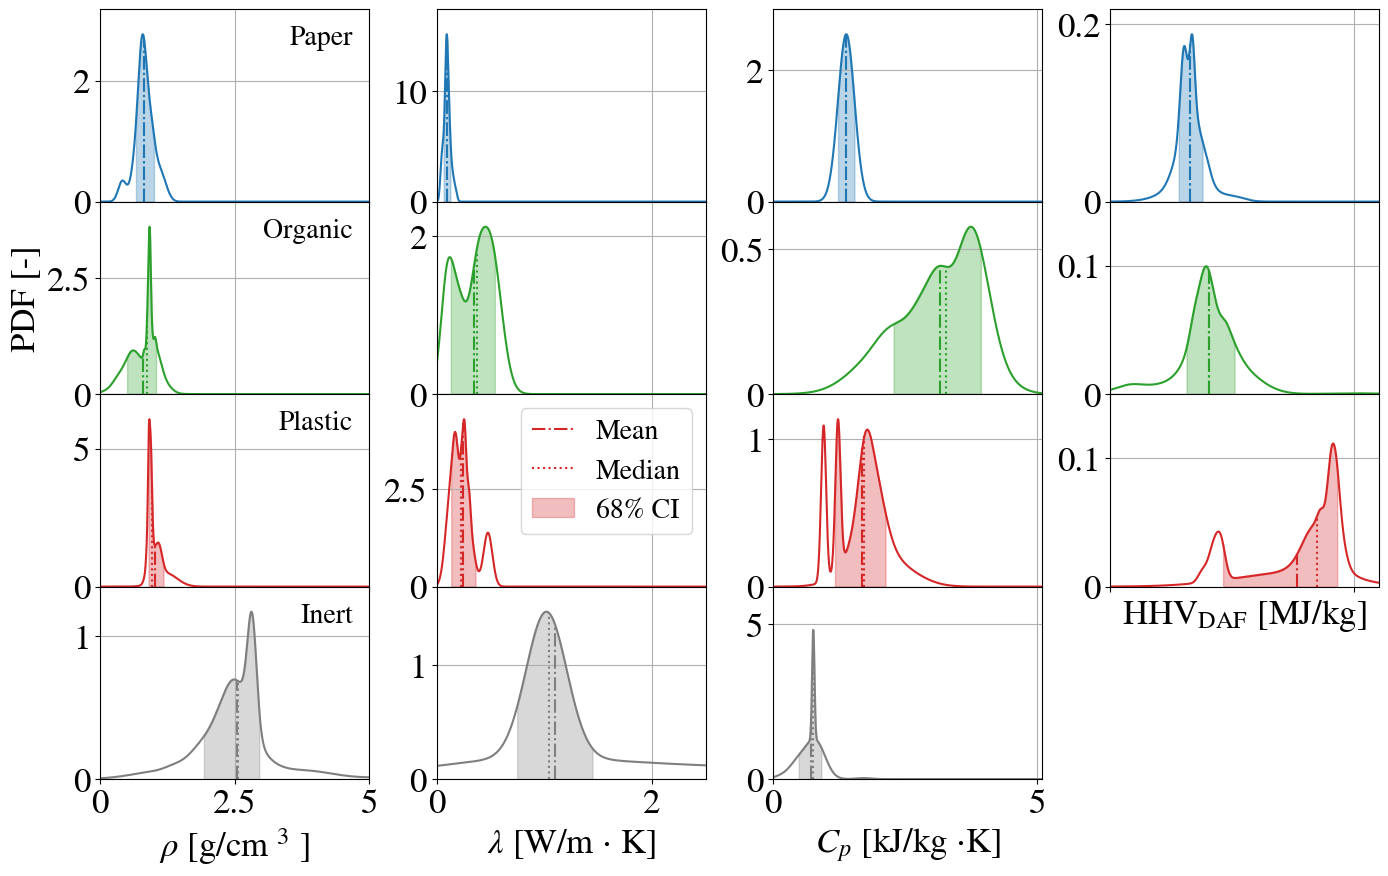

In [86]:
fig = plt.figure(figsize=(16.5, 10.),facecolor = 'w')
gs = fig.add_gridspec(4,4, hspace=0.0, wspace=0.25)
ax = gs.subplots(sharex='col')

for j in range(4): # for the PA elements
    for i in range(4):
        if (j==3 and i==3):
            
            continue
            
        else:
            
            x_arg = x_grid_main_TPP[j,:] 
            arg = pdf_main_TPP[i,j,:]
            
            ax[i,j].plot(x_arg, arg,color=colors_main_group[i],)
            ax[i,j].grid()

            ax[i,j].set_ylim(0.,np.max(arg)*1.15)
            
            mu_pdf, sigma = moments_from_pdf(x_arg, arg)
            med_pdf= quantile_from_pdf(x_arg, arg, 0.5)
            lo = quantile_from_pdf(x_arg, arg, 0.16)
            hi = quantile_from_pdf(x_arg, arg, 0.84)
            y_mu = np.interp(mu_pdf,x_arg, arg)
            y_med = np.interp(med_pdf,x_arg, arg)
            ax[i,j].vlines(mu_pdf, 0., ymax=y_mu, color=colors_main_group[i], ls='-.', label='Mean')
            
            med_pdf= quantile_from_pdf(x_arg, arg, 0.5)
            y_med = np.interp(med_pdf,x_arg, arg)
            ax[i,j].vlines(med_pdf, 0., ymax=y_med, color=colors_main_group[i], ls=':', label='Median')
            
            mask = (x_arg  >= lo) & (x_arg <= hi)
            ax[i,j].fill_between(x_arg,  arg, where=mask, color=colors_main_group[i], alpha=0.3,label='68% CI')
    
            if i==2 and j==1:
                ax[i,j].legend(loc=1,fontsize=20,handlelength=1.5)
                
            if i==3:
                ax[i,j].set_xlabel(components_TPP[j])

for a in ax.flatten():
    a.xaxis.set_major_formatter(FormatStrFormatter('%.2g'))
    a.yaxis.set_major_formatter(FormatStrFormatter('%.2g'))

ax[3, 3].set_visible(False)

ax[0,0].set_xlim(0.,5.)
ax[0,1].set_xlim(0.,2.5)
ax[0,2].set_xlim(0.,5.1)
ax[0,3].set_xlim(0.,55.)

ax[2,3].set_xlabel(components_TPP[-1])

ax[3,2].set_ylim(0.,6.2)

ax[1,3].set_ylim(0.,0.15)
ax[2,3].set_ylim(0.,0.15)

ax[0,0].text(0.94, 0.85, "Paper", ha="right", va="center",  fontsize= 20., transform=ax[0,0].transAxes)
ax[1,0].text(0.94, 0.85, "Organic", ha="right", va="center",  fontsize= 20., transform=ax[1,0].transAxes)
ax[2,0].text(0.94, 0.85, "Plastic", ha="right", va="center",  fontsize= 20., transform=ax[2,0].transAxes)
ax[3,0].text(0.94, 0.85, "Inert", ha="right", va="center",  fontsize= 20., transform=ax[3,0].transAxes)

ax[1,0].set_ylabel('PDF [-]')
plt.show()

# 4.- Thermophysical properties of waste samples

In [88]:
# ------------------------------------------------------------------
# Load pre-computed PDFs for Thermophysical Properties (TPP)
# – Waste Samples
# ------------------------------------------------------------------
# File contains probability density functions (PDFs) for:
#   - 4 waste samples: A (Baseline), B (S1), C (S2), D (S3)
#   - 4 thermophysical properties:
#         0 = Density (rho)
#         1 = Thermal conductivity (k)
#         2 = Heat capacity (cp)
#         3 = Higher heating value (hhv)
#
# IMPORTANT:
# Unlike PA and EA, each property has its own evaluation grid.
# Therefore, both:
#   - x_grid_waste_TPP  (property-specific grids)
#   - pdf_waste_TPP     (corresponding PDFs)
# are stored as 3D arrays.
# ------------------------------------------------------------------

TPP_waste_samples = pd.read_csv("../data/pdfs/TPP/PDFs_TPP_waste_samples_1000k_cases.csv", delimiter=',')

# Preallocate arrays
#
# Dimensions: axis 0 → waste sample index (0 = A, 1 = B, 2 = C, 3 = D)
#             axis 1 → property index (0 = rho, 1 = k. 2 = cp, 3 = hhv)#
#             axis 2 → property-specific x-grid
x_grid_waste_TPP = np.zeros((4, 4, len(TPP_waste_samples['x_rho_A'])), dtype=np.float64)
pdf_waste_TPP = np.zeros((4, 4, len(TPP_waste_samples['x_rho_A'])), dtype=np.float64)

# ------------------------------------------------------------------
# Assign property-specific x-grids
# ------------------------------------------------------------------

# Density (rho)
x_grid_waste_TPP[0,0,:] = TPP_waste_samples['x_rho_A'].to_numpy()
x_grid_waste_TPP[1,0,:] = TPP_waste_samples['x_rho_B'].to_numpy()
x_grid_waste_TPP[2,0,:] = TPP_waste_samples['x_rho_C'].to_numpy()
x_grid_waste_TPP[3,0,:] = TPP_waste_samples['x_rho_D'].to_numpy()

# Thermal conductivity (k)
x_grid_waste_TPP[0,1,:] = TPP_waste_samples['x_k_A'].to_numpy()
x_grid_waste_TPP[1,1,:] = TPP_waste_samples['x_k_B'].to_numpy()
x_grid_waste_TPP[2,1,:] = TPP_waste_samples['x_k_C'].to_numpy()
x_grid_waste_TPP[3,1,:] = TPP_waste_samples['x_k_D'].to_numpy()

# Heat capacity (cp)
x_grid_waste_TPP[0,2,:] = TPP_waste_samples['x_cp_A'].to_numpy()
x_grid_waste_TPP[1,2,:] = TPP_waste_samples['x_cp_B'].to_numpy()
x_grid_waste_TPP[2,2,:] = TPP_waste_samples['x_cp_C'].to_numpy()
x_grid_waste_TPP[3,2,:] = TPP_waste_samples['x_cp_D'].to_numpy()

# Higher heating value (hhv)
x_grid_waste_TPP[0,3,:] = TPP_waste_samples['x_hhv_A'].to_numpy()
x_grid_waste_TPP[1,3,:] = TPP_waste_samples['x_hhv_B'].to_numpy()
x_grid_waste_TPP[2,3,:] = TPP_waste_samples['x_hhv_C'].to_numpy()
x_grid_waste_TPP[3,3,:] = TPP_waste_samples['x_hhv_D'].to_numpy()


# ------------------------------------------------------------------
# Assign corresponding PDFs
# ------------------------------------------------------------------

# Density (rho)
pdf_waste_TPP[0,0,:] = TPP_waste_samples['rho_A'].to_numpy()
pdf_waste_TPP[1,0,:] = TPP_waste_samples['rho_B'].to_numpy()
pdf_waste_TPP[2,0,:] = TPP_waste_samples['rho_C'].to_numpy()
pdf_waste_TPP[3,0,:] = TPP_waste_samples['rho_D'].to_numpy()

# Thermal conductivity (k)
pdf_waste_TPP[0,1,:] = TPP_waste_samples['k_A'].to_numpy()
pdf_waste_TPP[1,1,:] = TPP_waste_samples['k_B'].to_numpy()
pdf_waste_TPP[2,1,:] = TPP_waste_samples['k_C'].to_numpy()
pdf_waste_TPP[3,1,:] = TPP_waste_samples['k_D'].to_numpy()

# Heat capacity (cp)
pdf_waste_TPP[0,2,:] = TPP_waste_samples['cp_A'].to_numpy()
pdf_waste_TPP[1,2,:] = TPP_waste_samples['cp_B'].to_numpy()
pdf_waste_TPP[2,2,:] = TPP_waste_samples['cp_C'].to_numpy()
pdf_waste_TPP[3,2,:] = TPP_waste_samples['cp_D'].to_numpy()

# Higher heating value (hhv)
pdf_waste_TPP[0,3,:] = TPP_waste_samples['hhv_A'].to_numpy()
pdf_waste_TPP[1,3,:] = TPP_waste_samples['hhv_B'].to_numpy()
pdf_waste_TPP[2,3,:] = TPP_waste_samples['hhv_C'].to_numpy()
pdf_waste_TPP[3,3,:] = TPP_waste_samples['hhv_D'].to_numpy()

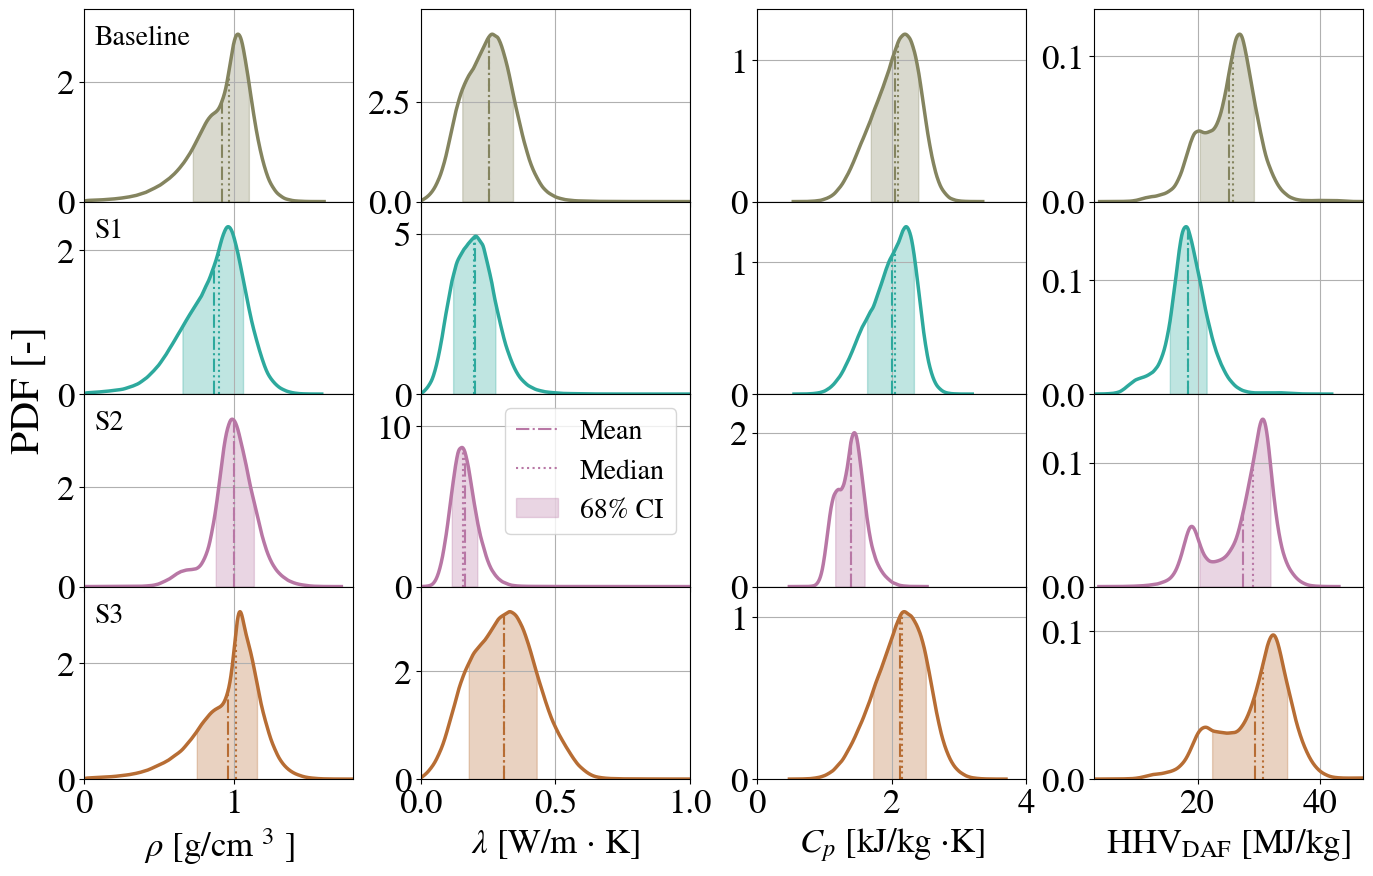

In [90]:
fig = plt.figure(figsize=(16.5,10.),facecolor = 'w')
gs = fig.add_gridspec(4, 4, hspace=0.0, wspace=0.25)
ax = gs.subplots(sharex='col')

for j in range(4): # per property
    for i in range(4):  # per sample      

        arg = pdf_waste_TPP[i,j,:] 
        x_arg = x_grid_waste_TPP[i,j,:]
        
        ax[i,j].plot(x_arg, arg, color = colors_waste_samples[i],lw=2.5)        
        
        mu_pdf, sigma = moments_from_pdf(x_arg, arg)
        med_pdf= quantile_from_pdf(x_arg, arg, 0.5)
        lo = quantile_from_pdf(x_arg, arg, 0.16)
        hi = quantile_from_pdf(x_arg, arg, 0.84)
        y_mu = np.interp(mu_pdf,x_arg, arg)
        y_med = np.interp(med_pdf,x_arg, arg)
        ax[i,j].vlines(mu_pdf, 0., ymax=y_mu, color=colors_waste_samples[i], ls='-.', label='Mean')
    
        med_pdf= quantile_from_pdf(x_arg, arg, 0.5)
        y_med = np.interp(med_pdf,x_arg, arg)
        ax[i,j].vlines(med_pdf, 0., ymax=y_med, color=colors_waste_samples[i], ls=':', label='Median')
        
        mask = (x_arg  >= lo) & (x_arg <= hi)
        ax[i,j].fill_between(x_arg,  arg, where=mask, color=colors_waste_samples[i], alpha=0.3,label='68% CI')

        ax[i,j].grid()
        
        ax[i,j].set_ylim(0.,np.max(arg)*1.15)

        ax[i,j].set_xlim(0.,np.max(x_arg))
        
        if i==2 and j==1:
            ax[i,j].legend(loc=1,fontsize=20,handlelength=1.5)

        if i==3:
            ax[i,j].set_xlabel(components_TPP[j])
            
ax[1,1].set_ylim(0.,6.)
ax[2,1].set_ylim(0.,12.)
ax[2,2].set_ylim(0.,2.5)
ax[3,3].set_ylim(0.,0.13)

ax[3,3].set_xlim(3.,47.)
ax[3,0].set_xlim(0.,1.8)
ax[3,1].set_xlim(0.,1.)
ax[3,2].set_xlim(0.,4.)

ax[0,0].text(0.04, 0.85, "Baseline", ha="left", va="center",  fontsize= 20., transform=ax[0,0].transAxes)
ax[1,0].text(0.04, 0.85, "S1", ha="left", va="center",  fontsize= 20., transform=ax[1,0].transAxes)
ax[2,0].text(0.04, 0.85, "S2", ha="left", va="center",  fontsize= 20., transform=ax[2,0].transAxes)
ax[3,0].text(0.04, 0.85, "S3", ha="left", va="center",  fontsize= 20., transform=ax[3,0].transAxes)

fig.supylabel('PDF [-]', x=0.08)

plt.show()

# 5.- Proximate analysis of main groups

In [61]:
# ------------------------------------------------------------------
# Load pre-computed PDFs for Proximate Analysis (PA) – Main Groups
# ------------------------------------------------------------------
# File contains probability density functions (PDFs) for:
#   - 3 main material groups: Paper, Organic, Plastic
#   - 4 PA components: Water, Volatile Matter, Char, Ash
#
# Each column corresponds to one (component, main group) combination.
# The PDFs are evaluated on a common grid 'x_PA'.
# ------------------------------------------------------------------
PA_main_groups = pd.read_csv("../data/pdfs/PA/PDFs_PA_main_groups_1000k_cases.csv", delimiter=',')

# Common evaluation grid for PA mass fractions
x_grid_A = PA_main_groups['x_PA'].to_numpy()

# Preallocate 3D array:
# Dimensions:
#   axis 0 → main group index (0 = Paper, 1 = Organic, 2 = Plastic)
#   axis 1 → PA component index (0 = Water, 1 = Volatile Matter, 2 = Char, 3 = Ash)
#   axis 2 → x-grid points
pdf_main_PA = np.zeros((3, 4, len(x_grid_A)), dtype=np.float64)

# --------------------------
# Moisture content PDFs
# --------------------------
pdf_main_PA[0,0,:] = PA_main_groups['Water_Paper'].to_numpy()
pdf_main_PA[1,0,:] = PA_main_groups['Water_Organic'].to_numpy()
pdf_main_PA[2,0,:] = PA_main_groups['Water_Plastic'].to_numpy()

# --------------------------
# Volatile Matter PDFs
# --------------------------
pdf_main_PA[0,1,:] = PA_main_groups['Vol_M_Paper'].to_numpy()
pdf_main_PA[1,1,:] = PA_main_groups['Vol_M_Organic'].to_numpy()
pdf_main_PA[2,1,:] = PA_main_groups['Vol_M_Plastic'].to_numpy()

# --------------------------
# Char PDFs
# --------------------------
pdf_main_PA[0,2,:] = PA_main_groups['Char_Paper'].to_numpy()
pdf_main_PA[1,2,:] = PA_main_groups['Char_Organic'].to_numpy()
pdf_main_PA[2,2,:] = PA_main_groups['Char_Plastic'].to_numpy()

# --------------------------
# Ash PDFs
# --------------------------
pdf_main_PA[0,3,:] = PA_main_groups['Ash_Paper'].to_numpy()
pdf_main_PA[1,3,:] = PA_main_groups['Ash_Organic'].to_numpy()
pdf_main_PA[2,3,:] = PA_main_groups['Ash_Plastic'].to_numpy()

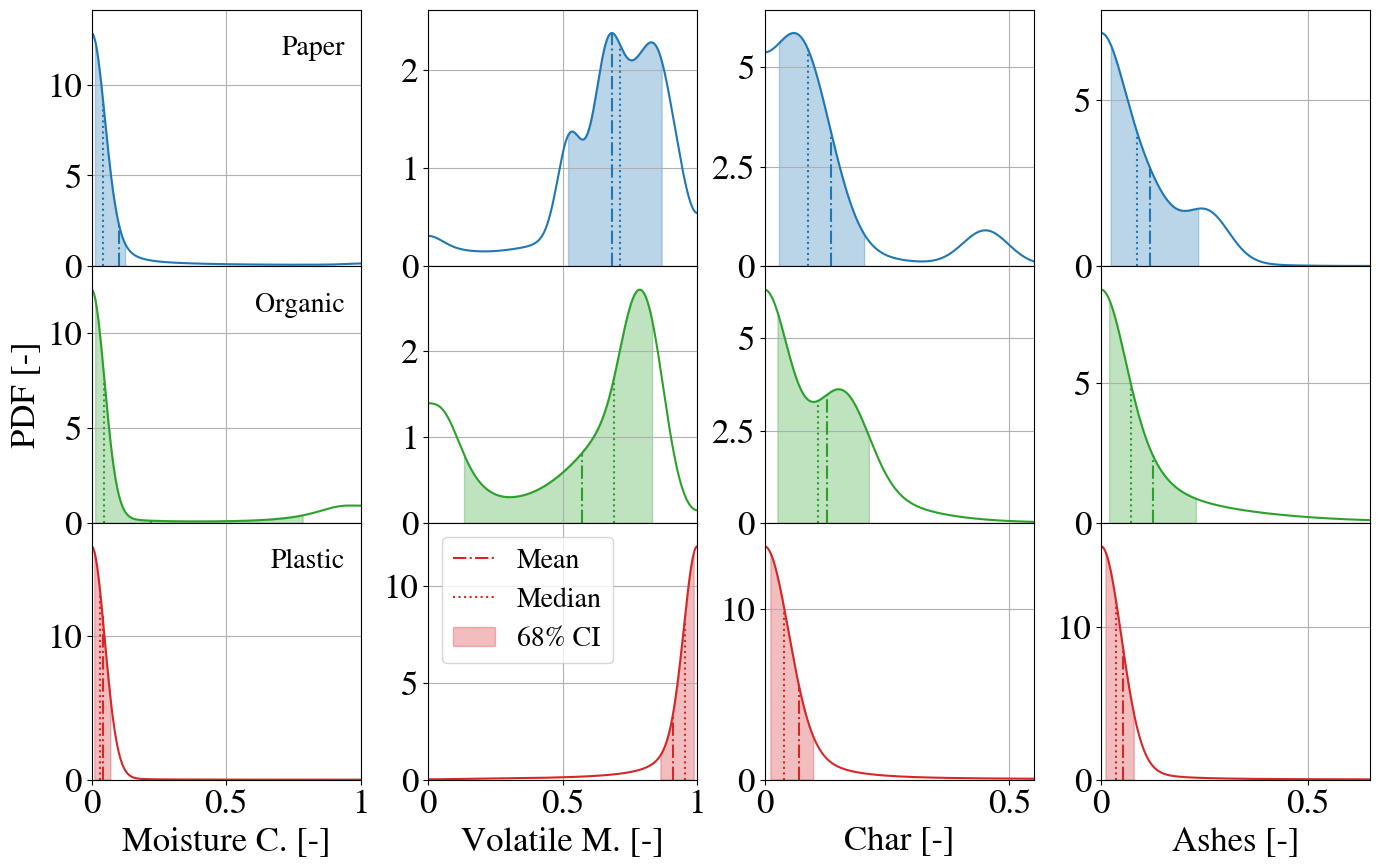

In [63]:
fig = plt.figure(figsize=(16.5, 10.),facecolor = 'w')
gs = fig.add_gridspec(3,4, hspace=0.0, wspace=0.25)
ax = gs.subplots(sharex='col')

for j in range(4): # for the PA elements
    for i in range(3):
    
        x_arg = x_grid_A
        arg = pdf_main_PA[i,j,:]
        
        ax[i,j].plot(x_arg, arg,color=colors_main_group[i],)
        ax[i,j].grid()
        ax[i,j].set_xlim(0.,1.)
    
        mu_pdf, sigma = moments_from_pdf(x_arg, arg)
        med_pdf= quantile_from_pdf(x_arg, arg, 0.5)
        lo = quantile_from_pdf(x_arg, arg, 0.16)
        hi = quantile_from_pdf(x_arg, arg, 0.84)
        y_mu = np.interp(mu_pdf,x_arg, arg)
        y_med = np.interp(med_pdf,x_arg, arg)
        ax[i,j].vlines(mu_pdf, 0., ymax=y_mu, color=colors_main_group[i], ls='-.', label='Mean')
        
        med_pdf= quantile_from_pdf(x_arg, arg, 0.5)
        y_med = np.interp(med_pdf,x_arg, arg)
        ax[i,j].vlines(med_pdf, 0., ymax=y_med, color=colors_main_group[i], ls=':', label='Median')
        
        mask = (x_arg  >= lo) & (x_arg <= hi)
        ax[i,j].fill_between(x_arg,  arg, where=mask, color=colors_main_group[i], alpha=0.3,label='68% CI')
    
        ax[i,j].set_ylim(0.,np.max(arg)*1.1)

        if i==2 and j==1:
            ax[i,j].legend(loc=2,fontsize=20,handlelength=1.5)
            
        if i==2:
            ax[i,j].set_xlabel(components_PA[j])

for a in ax.flatten():
    a.xaxis.set_major_formatter(FormatStrFormatter('%.2g'))
    a.yaxis.set_major_formatter(FormatStrFormatter('%.2g'))
    
ax[0,2].set_xlim(0.,0.55)
ax[0,3].set_xlim(0.,0.65)
ax[0,0].text(0.94, 0.85, "Paper", ha="right", va="center",  fontsize= 20., transform=ax[0,0].transAxes)
ax[1,0].text(0.94, 0.85, "Organic", ha="right", va="center",  fontsize= 20., transform=ax[1,0].transAxes)
ax[2,0].text(0.94, 0.85, "Plastic", ha="right", va="center",  fontsize= 20., transform=ax[2,0].transAxes)

ax[1,0].set_ylabel('PDF [-]')
plt.show()

# 6.- Proximate analysis of waste samples

In [11]:
# ------------------------------------------------------------------
# Load pre-computed PDFs for Proximate Analysis (PA)
# ------------------------------------------------------------------
# File contains probability density functions (PDFs) for:
#   - 4 waste samples: A -> Baseline, B -> S1, C -> S2, D -> S3
#   - 4 PA components: Water, Volatile Matter, Char, Ash
#
# Each column corresponds to one (component, sample) combination.
# The PDFs are evaluated on a common x-grid stored as 'x_PA'.
# ------------------------------------------------------------------

PA_waste_samples = pd.read_csv("../data/pdfs/PA/PDFs_PA_waste_samples_1000k_cases.csv", delimiter=',')

# Common evaluation grid for PA mass fractions
x_grid_A = PA_waste_samples['x_PA'].to_numpy()

# Preallocate 3D array:
# Dimensions:
#   axis 0 → waste sample index  (0=A, 1=B, 2=C, 3=D)
#   axis 1 → PA component index  (0=Water, 1=Vol_M, 2=Char, 3=Ash)
#   axis 2 → x-grid points
pdf_waste_PA = np.zeros((4, 4, len(x_grid_A)), dtype=np.float64)

# --------------------------
# Moisture Content PDFs
# --------------------------
pdf_waste_PA[0,0,:] = PA_waste_samples['Water_A'].to_numpy()
pdf_waste_PA[1,0,:] = PA_waste_samples['Water_B'].to_numpy()
pdf_waste_PA[2,0,:] = PA_waste_samples['Water_C'].to_numpy()
pdf_waste_PA[3,0,:] = PA_waste_samples['Water_D'].to_numpy()

# --------------------------
# Volatile Matter PDFs
# --------------------------
pdf_waste_PA[0,1,:] = PA_waste_samples['Vol_M_A'].to_numpy()
pdf_waste_PA[1,1,:] = PA_waste_samples['Vol_M_B'].to_numpy()
pdf_waste_PA[2,1,:] = PA_waste_samples['Vol_M_C'].to_numpy()
pdf_waste_PA[3,1,:] = PA_waste_samples['Vol_M_D'].to_numpy()

# --------------------------
# Char PDFs
# --------------------------
pdf_waste_PA[0,2,:] = PA_waste_samples['Char_A'].to_numpy()
pdf_waste_PA[1,2,:] = PA_waste_samples['Char_B'].to_numpy()
pdf_waste_PA[2,2,:] = PA_waste_samples['Char_C'].to_numpy()
pdf_waste_PA[3,2,:] = PA_waste_samples['Char_D'].to_numpy()

# --------------------------
# Ash PDFs
# --------------------------
pdf_waste_PA[0,3,:] = PA_waste_samples['Ash_A'].to_numpy()
pdf_waste_PA[1,3,:] = PA_waste_samples['Ash_B'].to_numpy()
pdf_waste_PA[2,3,:] = PA_waste_samples['Ash_C'].to_numpy()
pdf_waste_PA[3,3,:] = PA_waste_samples['Ash_D'].to_numpy()


C:\Users\ge84jeg\AppData\Local\Temp\ipykernel_10208\1651597535.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pdf = pdf / np.trapz(pdf, x)
C:\Users\ge84jeg\AppData\Local\Temp\ipykernel_10208\1651597535.py:37: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mu = np.trapz(x * pdf, x)
C:\Users\ge84jeg\AppData\Local\Temp\ipykernel_10208\1651597535.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  var = np.trapz((x - mu)**2 * pdf, x)
C:\Users\ge84jeg\AppData\Local\Temp\ipykernel_10208\1651597535.py:85: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pdf = pdf / np.trapz(pdf, x)


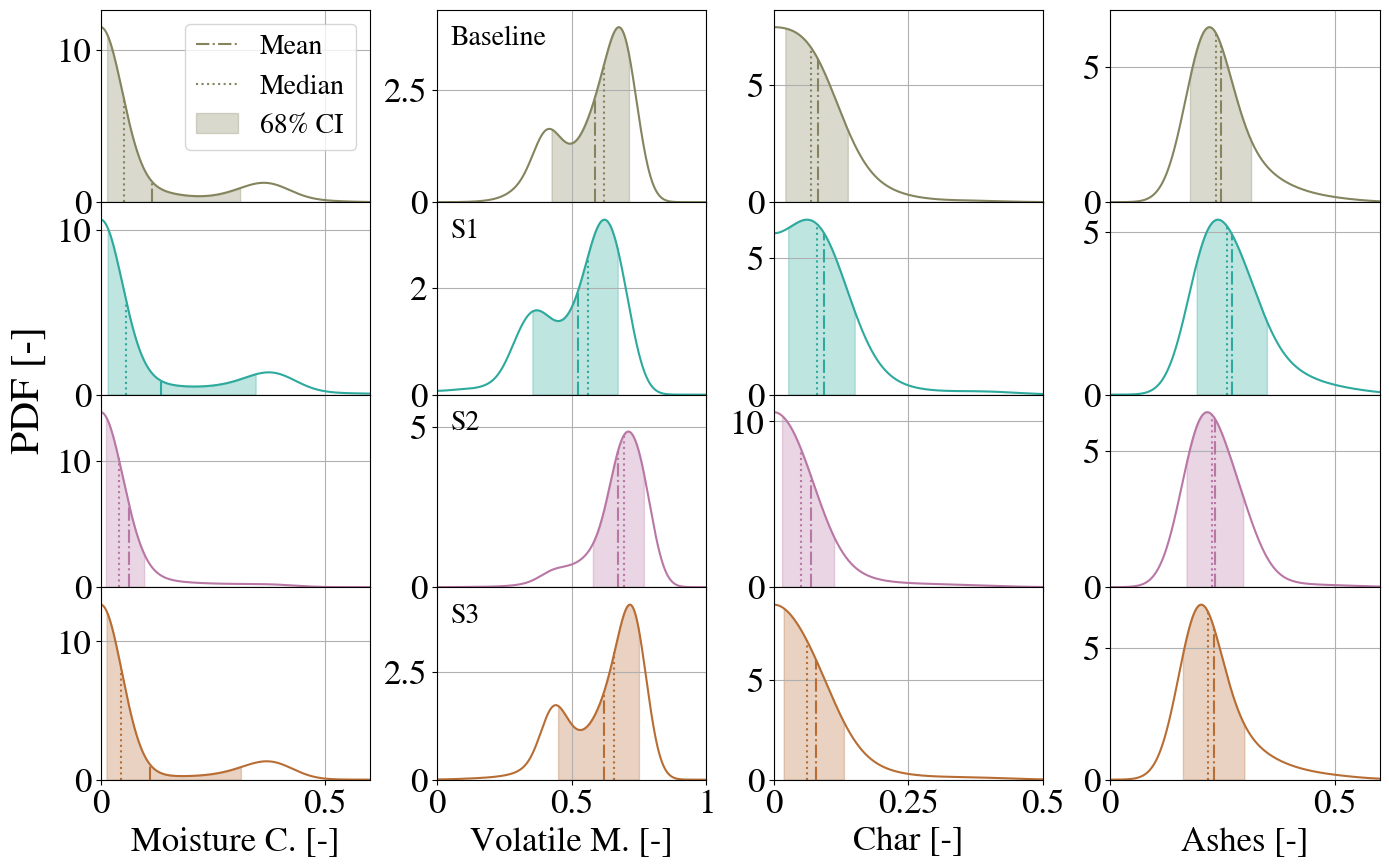

In [12]:

fig = plt.figure(figsize=(16.5, 10.),facecolor = 'w')
gs = fig.add_gridspec(4,4, hspace=0.0, wspace=0.25)
ax = gs.subplots(sharex='col')

for j in range(4): # for the PA elements
    for i in range(4):
        x_arg = x_grid_A
        arg = pdf_waste_PA[i,j]
        
        ax[i,j].plot(x_arg, arg,color=colors_waste_samples[i])
        ax[i,j].grid()
        ax[i,j].set_xlim(0.,1.)

        mu_pdf, sigma = moments_from_pdf(x_arg, arg)
        med_pdf= quantile_from_pdf(x_arg, arg, 0.5)
        lo = quantile_from_pdf(x_arg, arg, 0.16)
        hi = quantile_from_pdf(x_arg, arg, 0.84)
        y_mu = np.interp(mu_pdf,x_arg, arg)
        y_med = np.interp(med_pdf,x_arg, arg)
        ax[i,j].vlines(mu_pdf, 0., ymax=y_mu, color=colors_waste_samples[i], ls='-.', label='Mean')
        
        med_pdf= quantile_from_pdf(x_arg, arg, 0.5)
        y_med = np.interp(med_pdf,x_arg, arg)
        ax[i,j].vlines(med_pdf, 0., ymax=y_med, color=colors_waste_samples[i], ls=':', label='Median')
        
        mask = (x_arg  >= lo) & (x_arg <= hi)
        ax[i,j].fill_between(x_arg,  arg, where=mask, color=colors_waste_samples[i], alpha=0.3,label='68% CI')
    
        ax[i,j].set_ylim(0.,np.max(arg)*1.1)

        if i==0 and j==0:
            ax[i,j].legend(loc=1,fontsize=20,handlelength=1.5)
       
        if i==3:
            ax[i,j].set_xlabel(components_PA[j])

for a in ax.flatten():
    a.xaxis.set_major_formatter(FormatStrFormatter('%.2g'))
    a.yaxis.set_major_formatter(FormatStrFormatter('%.2g'))
    
ax[2,1].set_ylim(0.,6.)

ax[0,0].set_xlim(0.,0.6)
ax[0,2].set_xlim(0.,0.5)
ax[0,3].set_xlim(0.,0.6)

ax[0,1].text(0.05, 0.85, "Baseline", ha="left", va="center",  fontsize= 20., transform=ax[0,1].transAxes)
ax[1,1].text(0.05, 0.85, "S1"      , ha="left", va="center",  fontsize= 20., transform=ax[1,1].transAxes)
ax[2,1].text(0.05, 0.85, "S2"      , ha="left", va="center",  fontsize= 20., transform=ax[2,1].transAxes)
ax[3,1].text(0.05, 0.85, "S3"      , ha="left", va="center",  fontsize= 20., transform=ax[3,1].transAxes)
    
fig.supylabel('PDF [-]', x=0.070)
plt.show()

# 7.- Elemental analysis of main groups

In [65]:
# ------------------------------------------------------------------
# Load pre-computed PDFs for Elemental Analysis (EA) – Main Groups
# ------------------------------------------------------------------
# File contains probability density functions (PDFs) for:
#   - 3 main groups: Paper, Organic, Plastic
#   - 5 elemental components: C, H, N, S, O
#
# The PDFs are evaluated on a common mass fraction grid 'x_EA'.
# ------------------------------------------------------------------

EA_main_groups = pd.read_csv("../data/pdfs/EA/PDFs_EA_main_groups_1000k_cases.csv", delimiter=',')

# Common evaluation grid for EA mass fractions
x_grid_A = EA_main_groups['x_EA'].to_numpy()

# Preallocate 3D array:
# Dimensions:
#   axis 0 → main group index (0 = Paper, 1 = Organic, 2 = Plastic)
#   axis 1 → elemental component index (0 = C, 1 = H, 2 = N, 3 = S, 4 = O)
#   axis 2 → x-grid points
pdf_main_EA = np.zeros((3, 5, len(x_grid_A)), dtype=np.float64)

# --------------------------
# Carbon (C)
# --------------------------
pdf_main_EA[0,0,:] = EA_main_groups['C_Paper'].to_numpy()
pdf_main_EA[1,0,:] = EA_main_groups['C_Organic'].to_numpy()
pdf_main_EA[2,0,:] = EA_main_groups['C_Plastic'].to_numpy()

# --------------------------
# Hydrogen (H)
# --------------------------
pdf_main_EA[0,1,:] = EA_main_groups['H_Paper'].to_numpy()
pdf_main_EA[1,1,:] = EA_main_groups['H_Organic'].to_numpy()
pdf_main_EA[2,1,:] = EA_main_groups['H_Plastic'].to_numpy()

# --------------------------
# Nitrogen (N)
# --------------------------
pdf_main_EA[0,2,:] = EA_main_groups['N_Paper'].to_numpy()
pdf_main_EA[1,2,:] = EA_main_groups['N_Organic'].to_numpy()
pdf_main_EA[2,2,:] = EA_main_groups['N_Plastic'].to_numpy()

# --------------------------
# Sulfur (S)
# --------------------------
pdf_main_EA[0,3,:] = EA_main_groups['S_Paper'].to_numpy()
pdf_main_EA[1,3,:] = EA_main_groups['S_Organic'].to_numpy()
pdf_main_EA[2,3,:] = EA_main_groups['S_Plastic'].to_numpy()

# --------------------------
# Oxygen (O)
# --------------------------
pdf_main_EA[0,4,:] = EA_main_groups['O_Paper'].to_numpy()
pdf_main_EA[1,4,:] = EA_main_groups['O_Organic'].to_numpy()
pdf_main_EA[2,4,:] = EA_main_groups['O_Plastic'].to_numpy()

# ------------------------------------------------------------------
# Chlorine (Cl) PDFs
# ------------------------------------------------------------------
# Chlorine is treated separately from CHNSO.
# File contains PDFs for:
#   - Main groups
#   - Waste samples (A–D)
#
# All PDFs are evaluated on grid 'x_EA'.
# ------------------------------------------------------------------
Cl_EA_samples = pd.read_csv("../data/pdfs/EA/PDFs_EA_Cl_All_1000k_cases.csv", delimiter=',')

x_Cl = Cl_EA_samples['x_EA'].to_numpy()


# Main group Cl PDFs
# axis 0 → main group (0 = Paper, 1 = Organic, 2 = PVC, 3 = Plastic)
pdf_main_Cl = np.zeros((4, len(x_Cl)), dtype=np.float64)

pdf_main_Cl[0,:] = Cl_EA_samples['Cl_Paper'].to_numpy()
pdf_main_Cl[1,:] = Cl_EA_samples['Cl_Organic'].to_numpy()
pdf_main_Cl[2,:] = Cl_EA_samples['Cl_PVC'].to_numpy()
pdf_main_Cl[3,:] = Cl_EA_samples['Cl_Plastic'].to_numpy()

# Waste sample Cl PDFs
# axis 0 → waste sample (0 = A, 1 = B, 2 = C, 3 = D)
pdf_waste_Cl = np.zeros((4, len(x_Cl)), dtype=np.float64)

pdf_waste_Cl[0,:] = Cl_EA_samples['Cl_A'].to_numpy()
pdf_waste_Cl[1,:] = Cl_EA_samples['Cl_B'].to_numpy()
pdf_waste_Cl[2,:] = Cl_EA_samples['Cl_C'].to_numpy()
pdf_waste_Cl[3,:] = Cl_EA_samples['Cl_D'].to_numpy()

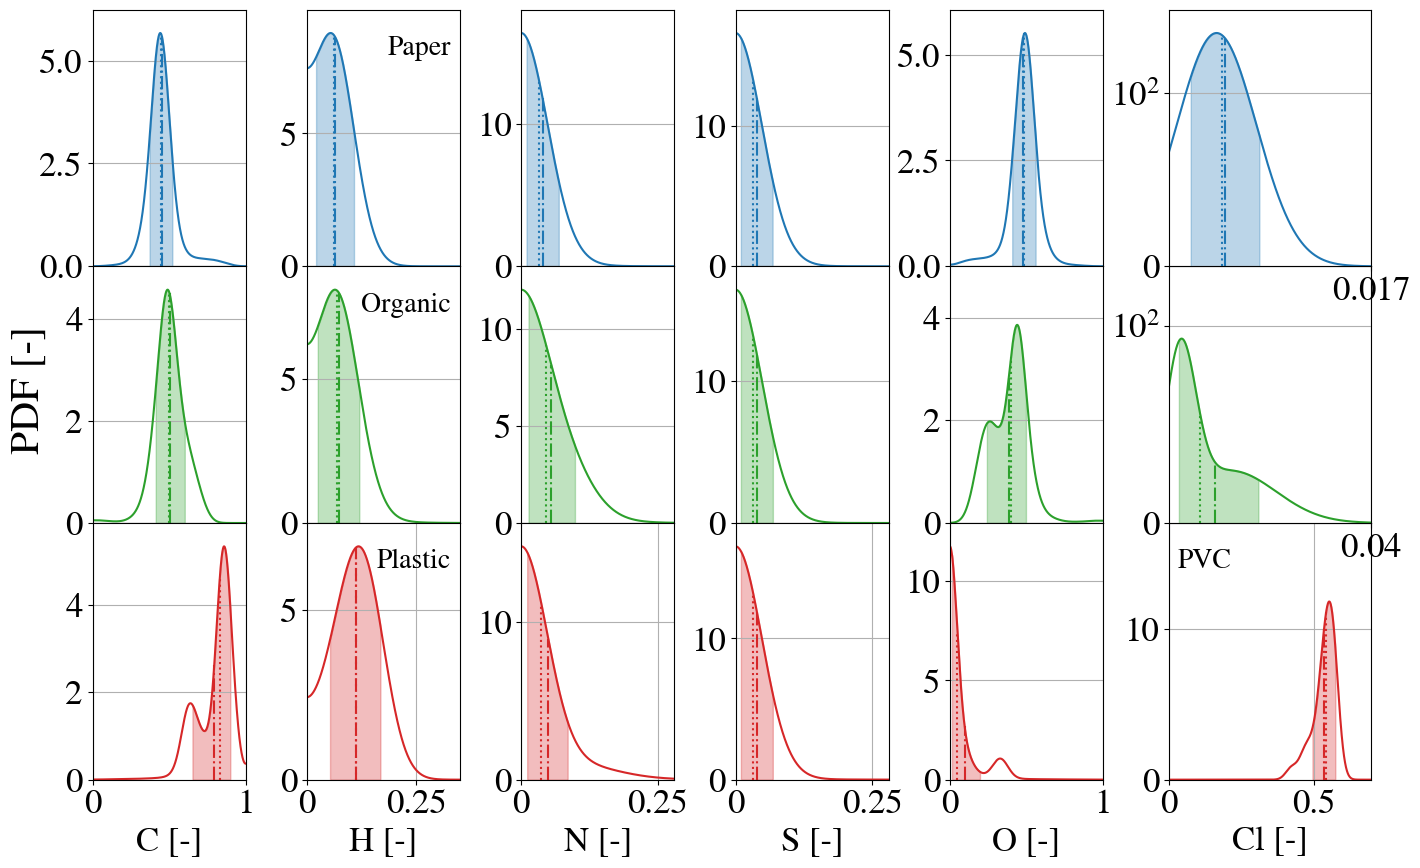

In [66]:

# ---- controls ----
w_left   = 0.4   # spacing inside columns 0..4
w_right  = 0.15   # spacing inside column 5 (not too relevant)
gap_w    = 0.10911    # EXTRA gap between col 4 and col 5  (increase if you want more)

fig = plt.figure(figsize=(16.5, 10.), facecolor='w')

# Outer: 1 row, 2 blocks (left 5 cols, right 1 col)
outer = fig.add_gridspec(
    1, 2,
    width_ratios=[5, 1],  # 5 columns vs 1 column
    wspace=gap_w
)

# Left block: 3x5
gsL = outer[0].subgridspec(3, 5, hspace=0.0, wspace=w_left)

# Right block: 3x1
gsR = outer[1].subgridspec(3, 1, hspace=0.0, wspace=w_right)

# Create axes explicitly (no global sharex)
axL = np.empty((3, 5), dtype=object)
axR = np.empty((3, 1), dtype=object)

for i in range(3):
    for j in range(5):
        axL[i, j] = fig.add_subplot(gsL[i, j])

for i in range(3):
    axR[i, 0] = fig.add_subplot(gsR[i, 0])

# Share x only within each left column (0..4)
for j in range(5):
    for i in range(1, 3):
        axL[i, j].sharex(axL[0, j])

# EA elements: j=0..4 -> axL
for j in range(5):
    for i in range(3):
        x_arg = x_grid_A
        arg   = pdf_main_EA[i, j]

        a = axL[i, j]
        a.plot(x_arg, arg, color=colors_main_group[i])
        a.grid()
        a.set_xlim(0., 1.)

        mu_pdf, sigma = moments_from_pdf(x_arg, arg)
        med_pdf = quantile_from_pdf(x_arg, arg, 0.5)
        lo      = quantile_from_pdf(x_arg, arg, 0.16)
        hi      = quantile_from_pdf(x_arg, arg, 0.84)

        y_mu  = np.interp(mu_pdf,  x_arg, arg)
        y_med = np.interp(med_pdf, x_arg, arg)

        a.vlines(mu_pdf,  0., ymax=y_mu,  color=colors_main_group[i], ls='-.', label='Mean')
        a.vlines(med_pdf, 0., ymax=y_med, color=colors_main_group[i], ls=':',  label='Median')

        mask = (x_arg >= lo) & (x_arg <= hi)
        a.fill_between(x_arg, arg, where=mask, color=colors_main_group[i], alpha=0.3, label='68% CI')

        a.set_ylim(0., np.max(arg)*1.1)

        if i == 2:
            a.set_xlabel(components_EA[j])

# Cl: column 5 -> axR (NO sharex)
for i in range(3):
    x_arg = x_Cl
    arg   = pdf_main_Cl[i, :]

    a = axR[i, 0]
    a.plot(x_arg, arg, color=colors_main_group[i])
    a.grid()
    a.set_xlim(0., 1.)

    mu_pdf, sigma = moments_from_pdf(x_arg, arg)
    med_pdf = quantile_from_pdf(x_arg, arg, 0.5)
    lo      = quantile_from_pdf(x_arg, arg, 0.16)
    hi      = quantile_from_pdf(x_arg, arg, 0.84)

    y_mu  = np.interp(mu_pdf,  x_arg, arg)
    y_med = np.interp(med_pdf, x_arg, arg)

    a.vlines(mu_pdf,  0., ymax=y_mu,  color=colors_main_group[i], ls='-.', label='Mean')
    a.vlines(med_pdf, 0., ymax=y_med, color=colors_main_group[i], ls=':',  label='Median')

    mask = (x_arg >= lo) & (x_arg <= hi)
    a.fill_between(x_arg, arg, where=mask, color=colors_main_group[i], alpha=0.3, label='68% CI')

    a.set_ylim(0., np.max(arg)*1.1)

    if i == 2:
        a.set_xlabel(components_EA[5])


for a in np.concatenate([axL.flatten(), axR.flatten()]):
    a.xaxis.set_major_formatter(FormatStrFormatter('%.2g'))


axL[1, 4].set_ylim(0., 5.)

axL[0, 1].set_xlim(0., 0.35)
axL[0, 2].set_xlim(0., 0.28)
axL[0, 3].set_xlim(0., 0.28)

axL[0, 1].text(0.94, 0.85, "Paper",   ha="right", va="center", fontsize=20., transform=axL[0, 1].transAxes)
axL[1, 1].text(0.94, 0.85, "Organic", ha="right", va="center", fontsize=20., transform=axL[1, 1].transAxes)
axL[2, 1].text(0.94, 0.85, "Plastic", ha="right", va="center", fontsize=20., transform=axL[2, 1].transAxes)
axR[2, 0].text(0.04, 0.85, "PVC", ha="left", va="center", fontsize=20., transform=axR[2, 0].transAxes)

axL[0,0].get_xaxis().set_visible(False)
axL[1,0].get_xaxis().set_visible(False)

axL[0,1].get_xaxis().set_visible(False)
axL[1,1].get_xaxis().set_visible(False)

axL[0,2].get_xaxis().set_visible(False)
axL[1,2].get_xaxis().set_visible(False)

axL[0,3].get_xaxis().set_visible(False)
axL[1,3].get_xaxis().set_visible(False)

axL[0,4].get_xaxis().set_visible(False)
axL[1,4].get_xaxis().set_visible(False)

axR[0, 0].set_xlim(0., 0.017)
axR[1, 0].set_xlim(0., 0.04)
axR[2, 0].set_xlim(0., 0.70)

axR[1, 0].set_ylim(0., 130)
axR[2, 0].set_ylim(0., 17)

axR[0,0].set_yticks([0.,100])
axR[0,0].set_yticklabels(['0','$10^2$'])

axR[1,0].set_yticks([0.,100])
axR[1,0].set_yticklabels(['0','$10^2$'])

axR[0,0].set_xticks([0.017])
axR[0,0].set_xticklabels(['$0.017$'])

axR[1,0].set_xticks([0.04])
axR[1,0].set_xticklabels(['$0.04$'])

for a in [axR[0,0], axR[1,0]]:
    
    a.xaxis.set_ticks_position('bottom')
    a.xaxis.set_label_position('bottom')
    

    a.tick_params(axis='x')            
    
    a.spines['top'].set_position(('axes', 1.0))

axR[2,0].set_zorder(1)
axR[1,0].set_zorder(2)
axR[0,0].set_zorder(3)

for a in axR.flatten():
    a.patch.set_alpha(1.0)  

fig.supylabel('PDF [-]', x=0.075)
plt.show()


# 8.- Elemental analysis of waste samples

In [17]:
# ------------------------------------------------------------------
# Load pre-computed PDFs for Elemental Analysis (EA) – Waste Samples
# ------------------------------------------------------------------
# File contains probability density functions (PDFs) for:
#   - 4 waste samples: A (Baseline), B (S1), C (S2), D (S3)
#   - 5 elemental components: C, H, N, S, O
#
# All PDFs are evaluated on a common mass fraction grid 'x_EA'.
# ------------------------------------------------------------------

EA_waste_samples = pd.read_csv("../data/pdfs/EA/PDFs_EA_waste_samples_1000k_cases.csv", delimiter=',')

# Common evaluation grid for EA mass fractions
x_grid_A = EA_waste_samples['x_EA'].to_numpy()

# Preallocate 3D array:
# Dimensions:
#   axis 0 → waste sample index (0 = A, 1 = B, 2 = C, 3 = D) 
#   axis 1 → elemental component index (0 = C, 1 = H, 2 = N, 3 = S, 4 = O)
#   axis 2 → x-grid points
pdf_waste_EA = np.zeros((4, 5, len(x_grid_A)), dtype=np.float64)

# --------------------------
# Carbon (C) PDFs
# --------------------------
pdf_waste_EA[0,0,:] = EA_waste_samples ['C_A'].to_numpy()
pdf_waste_EA[1,0,:] = EA_waste_samples ['C_B'].to_numpy()
pdf_waste_EA[2,0,:] = EA_waste_samples ['C_C'].to_numpy()
pdf_waste_EA[3,0,:] = EA_waste_samples ['C_D'].to_numpy()

# --------------------------
# Hydrogen (H) PDFs
# --------------------------
pdf_waste_EA[0,1,:] = EA_waste_samples ['H_A'].to_numpy()
pdf_waste_EA[1,1,:] = EA_waste_samples ['H_B'].to_numpy()
pdf_waste_EA[2,1,:] = EA_waste_samples ['H_C'].to_numpy()
pdf_waste_EA[3,1,:] = EA_waste_samples ['H_D'].to_numpy()

# --------------------------
# Nitrogen (N) PDFs
# --------------------------
pdf_waste_EA[0,2,:] = EA_waste_samples ['N_A'].to_numpy()
pdf_waste_EA[1,2,:] = EA_waste_samples ['N_B'].to_numpy()
pdf_waste_EA[2,2,:] = EA_waste_samples ['N_C'].to_numpy()
pdf_waste_EA[3,2,:] = EA_waste_samples ['N_D'].to_numpy()

# --------------------------
# Sulfur (S) PDFs
# --------------------------
pdf_waste_EA[0,3,:] = EA_waste_samples ['S_A'].to_numpy()
pdf_waste_EA[1,3,:] = EA_waste_samples ['S_B'].to_numpy()
pdf_waste_EA[2,3,:] = EA_waste_samples ['S_C'].to_numpy()
pdf_waste_EA[3,3,:] = EA_waste_samples ['S_D'].to_numpy()

# --------------------------
# Oxygen (O) PDFs
# --------------------------
pdf_waste_EA[0,4,:] = EA_waste_samples ['O_A'].to_numpy()
pdf_waste_EA[1,4,:] = EA_waste_samples ['O_B'].to_numpy()
pdf_waste_EA[2,4,:] = EA_waste_samples ['O_C'].to_numpy()
pdf_waste_EA[3,4,:] = EA_waste_samples ['O_D'].to_numpy()

C:\Users\ge84jeg\AppData\Local\Temp\ipykernel_10208\1651597535.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pdf = pdf / np.trapz(pdf, x)
C:\Users\ge84jeg\AppData\Local\Temp\ipykernel_10208\1651597535.py:37: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mu = np.trapz(x * pdf, x)
C:\Users\ge84jeg\AppData\Local\Temp\ipykernel_10208\1651597535.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  var = np.trapz((x - mu)**2 * pdf, x)
C:\Users\ge84jeg\AppData\Local\Temp\ipykernel_10208\1651597535.py:85: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pdf = pdf / np.trapz(pdf, x)


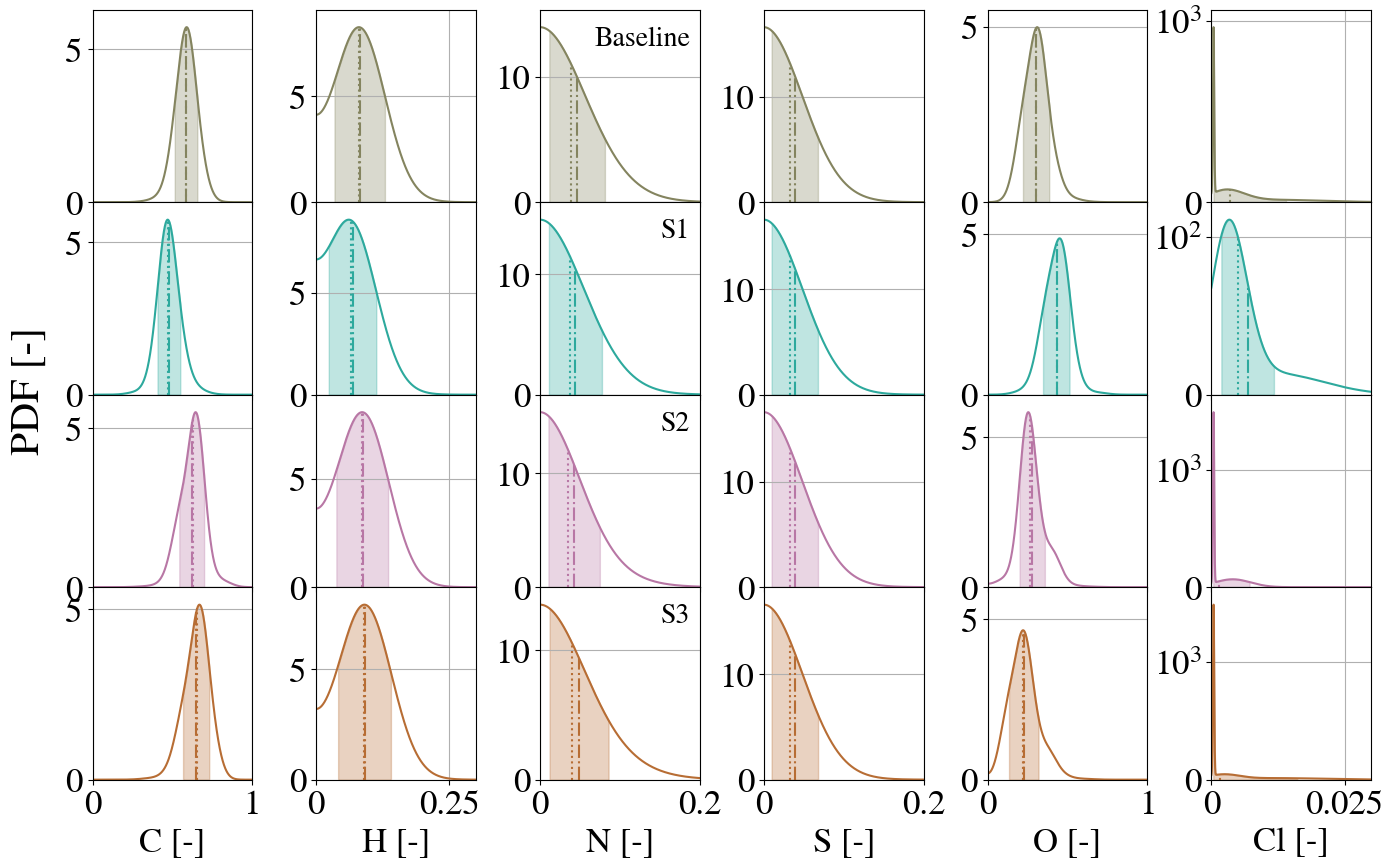

In [18]:
fig = plt.figure(figsize=(16.5, 10.),facecolor = 'w')
gs = fig.add_gridspec(4,6, hspace=0.0, wspace=0.4)
ax = gs.subplots(sharex='col')

for j in range(5): # for the EA elements
    for i in range(4):
        
        x_arg = x_grid_A
        arg = pdf_waste_EA[i,j]
        
        ax[i,j].plot(x_arg, arg,color=colors_waste_samples [i])
        ax[i,j].grid()
        ax[i,j].set_xlim(0.,1.)
    
        mu_pdf, sigma = moments_from_pdf(x_arg, arg)
        med_pdf= quantile_from_pdf(x_arg, arg, 0.5)
        lo = quantile_from_pdf(x_arg, arg, 0.16)
        hi = quantile_from_pdf(x_arg, arg, 0.84)
        y_mu = np.interp(mu_pdf,x_arg, arg)
        y_med = np.interp(med_pdf,x_arg, arg)
        ax[i,j].vlines(mu_pdf, 0., ymax=y_mu, color=colors_waste_samples [i], ls='-.', label='Mean')
        
        med_pdf= quantile_from_pdf(x_arg, arg, 0.5)
        y_med = np.interp(med_pdf,x_arg, arg)
        ax[i,j].vlines(med_pdf, 0., ymax=y_med, color=colors_waste_samples [i], ls=':', label='Median')
        
        mask = (x_arg  >= lo) & (x_arg <= hi)
        ax[i,j].fill_between(x_arg,  arg, where=mask, color=colors_waste_samples [i], alpha=0.3,label='68% CI')
    
        ax[i,j].set_ylim(0.,np.max(arg)*1.1)

       # print(j, mu_pdf)
       # if i==2 and j==2:
       #     ax[i,j].legend(loc=1,fontsize=20,handlelength=1.5)
            
        if i==3:
            ax[i,j].set_xlabel(components_EA[j])

j=5
for i in range(4):
        
        x_arg = x_Cl
        arg = pdf_waste_Cl[i,:]
        
        ax[i,j].plot(x_arg, arg,color=colors_waste_samples [i])
        ax[i,j].grid()
        ax[i,j].set_xlim(0.,1.)
    
        mu_pdf, sigma = moments_from_pdf(x_arg, arg)
        med_pdf= quantile_from_pdf(x_arg, arg, 0.5)
        lo = quantile_from_pdf(x_arg, arg, 0.16)
        hi = quantile_from_pdf(x_arg, arg, 0.84)
        y_mu = np.interp(mu_pdf,x_arg, arg)
        y_med = np.interp(med_pdf,x_arg, arg)
        ax[i,j].vlines(mu_pdf, 0., ymax=y_mu, color=colors_waste_samples [i], ls='-.', label='Mean')
        
        med_pdf= quantile_from_pdf(x_arg, arg, 0.5)
        y_med = np.interp(med_pdf,x_arg, arg)
        ax[i,j].vlines(med_pdf, 0., ymax=y_med, color=colors_waste_samples [i], ls=':', label='Median')
        
        mask = (x_arg  >= lo) & (x_arg <= hi)
        ax[i,j].fill_between(x_arg,  arg, where=mask, color=colors_waste_samples [i], alpha=0.3,label='68% CI')
    
        ax[i,j].set_ylim(0.,np.max(arg)*1.1)

        #if i==2 and j==5:
        #    ax[i,j].legend(loc=1,fontsize=20,handlelength=1.5)
            
        if i==3:
            ax[i,j].set_xlabel(components_EA[j])

for a in ax.flatten():
    a.xaxis.set_major_formatter(FormatStrFormatter('%.2g'))
    
#ax[3,0].set_ylim(0.,6.)
ax[1,4].set_ylim(0.,6.)
ax[3,4].set_ylim(0.,6.)

ax[0,1].set_xlim(0.,0.3)
ax[0,2].set_xlim(0.,0.2)
ax[0,3].set_xlim(0.,0.2)
ax[0,5].set_xlim(0.,0.03)

ax[0,2].text(0.94, 0.85, "Baseline", ha="right", va="center",  fontsize= 20., transform=ax[0,2].transAxes)
ax[1,2].text(0.94, 0.85, "S1", ha="right", va="center",  fontsize= 20., transform=ax[1,2].transAxes)
ax[2,2].text(0.94, 0.85, "S2", ha="right", va="center",  fontsize= 20., transform=ax[2,2].transAxes)
ax[3,2].text(0.94, 0.85, "S3", ha="right", va="center",  fontsize= 20., transform=ax[3,2].transAxes)

ax[0,5].set_yticks([0.,1000.])
ax[0,5].set_yticklabels(['0','$10^3$'])

ax[1,5].set_yticks([0.,100.])
ax[1,5].set_yticklabels(['0','$10^2$'])

ax[2,5].set_yticks([0.,1000.])
ax[2,5].set_yticklabels(['0','$10^3$'])

ax[3,5].set_yticks([0.,1000.])
ax[3,5].set_yticklabels(['0','$10^3$'])
#ax[0,5].tick_params(labelsize=9)
    
fig.supylabel('PDF [-]', x=0.075)
plt.show()